In [12]:
from astropy import units as u
from astropy.constants import G, c, M_jup
import numpy as np
from numpy import pi
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from math import gamma as Gamma
from scipy.integrate import quad
from datetime import datetime, timezone
import itertools
import h5py
import sys
import os


## Implementation

$$\langle \Delta v_{\parallel} \rangle = -16\pi^2G^2(m_f+m)m_f\ln\Lambda F_2(v)$$
$$\langle \Delta v^2_{\parallel} \rangle = \frac{32\pi^2}{3}G^2m_f^2\ln\Lambda[F_4(v)+E_1(v)]v$$
$$\langle \Delta v^2_{\perp} \rangle = \frac{32\pi^2}{3}G^2m_f^2\ln\Lambda[3F_2(v)-F_4(v)+2E_1(v)]v$$

$$E_n(v)=\int_v^\infty\left(\frac{v_f}{v}\right)^nf(v_f)dv_f$$
$$F_n(v)=\int_0^v\left(\frac{v_f}{v}\right)^nf(v_f)dv_f$$

$$f(E) = \frac{3 - \gamma}{8} \sqrt{\frac{2}{\pi^{5}}} \frac{\Gamma(\gamma + 1)}{\Gamma(\gamma - 1/2)} \frac{M_\bullet}{m_\star} \frac{\phi_0^{3/2}}{(GM_\bullet)^3} \left( \frac{|E|}{\phi_0} \right)^{\gamma - 3/2}$$

$$r_{\mathrm{inf}} = r_m = 1\mathrm{pc}\left(\frac{M_{\bullet}}{10^6 * M_{\odot}}\right)^{1/2}$$
$$\gamma=7/4\tag{Bahcall-Wolf}$$

In [13]:
#gamma_bw = 7/4 
#M_exp = 7
#M = 10**(M_exp) * u.Msun 
#mf = 0.3 * u.Msun 
#r_inf = 1* u.pc * (M / 1e6 / u.Msun) ** (0.5)
#n_inf = (3-gamma_bw)*M / (4*pi*mf * r_inf**3)


In [14]:
def f(M, r, v, mf, gamma_bw, r_inf):
    """Distribution function in terms of r, v. Merritt 3.49"""
    phi0 = G*M / r_inf
    Energy = (G*M)/r - 0.5*v**2
    Af = (3-gamma_bw)/8 * np.sqrt(2)/np.sqrt(pi**5)  * (Gamma(gamma_bw+1) / Gamma(gamma_bw - 1/2)) * (M/mf) * (phi0**(3/2) / (G*M)**3)
    return Af * (np.abs(Energy)/phi0)**(gamma_bw-3/2)

def _standard_integrand_EF(n, M, r, vf, v, mf, gamma_bw, r_inf):
    """Private helper method for functions E and F. f is evaluated at field-star speed vf."""
    return (vf/v)**n * f(M, r, vf, mf, gamma_bw, r_inf)

def E(n, M, r, v, mf, gamma_bw, r_inf):
    """ 'Standard' form integral used in diffusion coefficient calculation. Merritt 5.56a"""
    vu = v.unit
    v_esc = np.sqrt(2*G*M/r).to(vu).value
    gu = _standard_integrand_EF(n, M, r, v, v, mf, gamma_bw, r_inf).decompose().unit
    result, _ = quad(lambda vf: _standard_integrand_EF(n, M, r, vf*vu, v, mf, gamma_bw, r_inf).to_value(gu), v.to_value(vu), v_esc)
    return result * gu * vu

def F(n, M, r, v, mf, gamma_bw, r_inf):
    """ 'Standard' form integral used in diffusion coefficient calculation. Merritt 5.56b"""
    vu = v.unit
    gu = _standard_integrand_EF(n, M, r, v, v, mf, gamma_bw, r_inf).decompose().unit
    result, _ = quad(lambda vf: _standard_integrand_EF(n, M, r, vf*vu, v, mf, gamma_bw, r_inf).to_value(gu), 0, v.to_value(vu))
    return result * gu * vu

def sigma2(M, r, gamma_bw):
    """1D velocity dispersion of stars in the NSC"""
    return G * M / (r * (1+gamma_bw))

### Coulomb logarithm
$$\sigma^2(r)=\frac{GM}{r(1+\gamma)}$$
$$b_{max}=\frac{n(r)}{dn/dr}=r/\gamma \tag{from Merritt 3.48}$$
$$b_{min} = \frac{G(m+m_f)}{\sigma^2(r)} \tag{*}$$
$$\ln\Lambda = \ln\left(\frac{b_{max}}{b_{min}}\right)$$
*possibly missing a factor of 1/3 to match the Chandrasekhar convention?

In [15]:
def lnLambda(M, r, m, mf, gamma_bw):
    """Coulomb logaritm ?Maybe Chandrasekhar?"""
    b_max = r/gamma_bw #n(r)/(dn/dr) using equation 3.48 in Merritt
    b_min = G * (m+mf) / sigma2(M, r, gamma_bw) #! possibly missing a factor of 1/3 to match the Chandrasekhar convention?
    return np.log(b_max/b_min)

In [16]:
#Diffusion Coefficients — source?
def DC_1par(M, r, v, m, mf, gamma_bw, r_inf):
    """1st order parallel diffusion coefficient. Corresponds to dynamical friction."""
    return -16 * pi**2 * G**2 * (mf + m) * mf * lnLambda(M, r, m, mf, gamma_bw) * F(2, M, r, v, mf, gamma_bw, r_inf)

def DC_2par(M, r, v, m, mf, gamma_bw, r_inf):
    """2nd order parallel diffusion coefficient."""
    const = 32 * pi**2 * G**2 * mf**2 / 3
    return const * lnLambda(M, r, m, mf, gamma_bw) * (F(4, M, r, v, mf, gamma_bw, r_inf) + E(1, M, r, v, mf, gamma_bw, r_inf)) * v

def DC_2perp(M, r, v, m, mf, gamma_bw, r_inf):
    """2nd order perpendicular diffusion coefficient."""
    const = 32 * pi**2 * G**2 * mf**2 / 3
    return const * lnLambda(M, r, m, mf, gamma_bw) * (3*F(2, M, r, v, mf, gamma_bw, r_inf) - F(4, M, r, v, mf, gamma_bw, r_inf) + 2*E(1, M, r, v, mf, gamma_bw, r_inf)) * v

In [17]:
#========RELAXATION TIME==============
#! notes say to fix $v=\sqrt{\frac{GM_{\bullet}}{r}}$ for validation plots
#! I added a negative sign to the Dynamical Friction relaxation time because otherwise it is negative, and that did not make sense to me.
#! more common form would add a factor of 1/3 somewhere, but we are choosing to ignore that


def t_rel_DF(M, r, v, m, mf, gamma_bw, r_inf):
    """first order (dynamical friction) relaxation time"""
    dc = DC_1par(M, r, v, m, mf, gamma_bw, r_inf)
    sigma = np.sqrt(sigma2(M, r, gamma_bw))
    return -sigma/dc

def t_rel_2par(M, r, v, m, mf, gamma_bw, r_inf):
    """parallel second order relaxation time"""
    dc = DC_2par(M, r, v, m, mf, gamma_bw, r_inf)
    return sigma2(M, r, gamma_bw)/dc

def t_rel_2perp(M, r, v, m, mf, gamma_bw, r_inf):
    """perpdendicular second order relaxation time"""
    dc = DC_2perp(M, r, v, m, mf, gamma_bw, r_inf)
    return sigma2(M, r, gamma_bw)/dc

## Demonstration

Globally used parameters/Initial Conditions

In [18]:
# ---- Parameters that were previously globals (now passed explicitly) ----
M_exp = 7
M = 10**M_exp * u.Msun         # central black hole mass
mf = 0.3 * u.Msun              # field star mass (m_f)
gamma_bw = 7/4                 # Bahcall-Wolf slope
r_inf = 1 * u.pc * (M / 1e6 / u.Msun) ** (0.5)

m_test = 10 * u.Msun           # test particle mass
r_vals = np.linspace(0.01, 1, 100) * u.pc #100 values linspaced between 0 and 1 pc with astropy units attached

tr_df = []
tr_2par = []
tr_2perp = []

for r_i in r_vals:
    v_test = np.sqrt(G*M / r_i)  #! validation: fix v = sqrt(GM/r)
    tr_df_i = t_rel_DF(M, r_i, v_test, m_test, mf, gamma_bw, r_inf).to(u.Gyr)
    tr_2par_i = t_rel_2par(M, r_i, v_test, m_test, mf, gamma_bw, r_inf).to(u.Gyr)
    tr_2perp_i = t_rel_2perp(M, r_i, v_test, m_test, mf, gamma_bw, r_inf).to(u.Gyr)

    tr_df.append(tr_df_i)
    tr_2par.append(tr_2par_i)
    tr_2perp.append(tr_2perp_i)

Check:

**Ansatz $t^{x}_{rel}\propto r^{\alpha_x}, \mathrm{where}\  \alpha_x > 0$**

It is expected that $\alpha_{\parallel}=\alpha_{\perp}=\alpha_{\mathrm{DF}}=\gamma-3/2$

In [19]:
# numerically calculate alpha
fits = {}
for label, tr in [("DF", tr_df), ("par", tr_2par), ("perp", tr_2perp)]:
    alpha, log_C = np.polyfit(np.log(r_vals.value), np.log([t.value for t in tr]), 1)
    fits[label] = (alpha, log_C)
    print(f"alpha_{label} = {alpha:.3f}")

alpha_DF = 0.250
alpha_par = 0.250
alpha_perp = 0.250


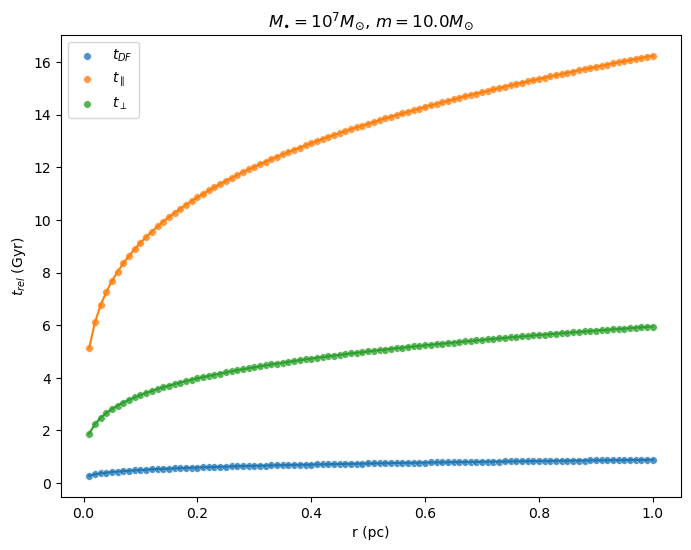

In [20]:
#plot each relaxation time t_rel(R) 

fig, ax = plt.subplots(figsize=(8,6))
ax.set_xlabel("r (pc)")
ax.set_ylabel(r"$t_{rel}$ (Gyr)")

r_pc = np.array([r.to(u.pc).value for r in r_vals])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (tr, label, key) in enumerate([(tr_df, r"$t_{DF}$", "DF"), (tr_2par, r"$t_{\parallel}$", "par"), (tr_2perp, r"$t_{\perp}$", "perp")]):
    alpha, log_C = fits[key]
    sns.scatterplot(x=r_pc, y=[t.to(u.Gyr).value for t in tr], ax=ax, label=label, color=colors[i], s=30, zorder=1, alpha=0.8)
    ax.plot(r_pc, np.exp(log_C) * r_pc**alpha, color=colors[i], linestyle='-', zorder=2)

ax.set_title(rf"$M_{{\bullet}}=10^{M_exp}M_{{\odot}}$, $m={m_test.value}M_{{\odot}}$")
ax.legend()
plt.show()

## Pre-tabulation → HDF5

All output lands in **one HDF5 file**, one `(r, v) → (F2, F4, E1)` "slab" per
combination of `(M_exp, m_star, gamma, r_inf)`. These three integrals are the
test-mass–independent ingredients; the diffusion coefficients
(`DC_1par/2par/2perp`) and relaxation times are reconstructed downstream from a
chosen test mass `m`, `lnLambda`, and these slabs.

**Units — SpaceHub natural** (`G=1`, length = AU, mass = M☉, time = yr/(2π)),
matching the `disk_tab/*.csv` convention consumed by `disk-model.hpp`.

**Velocity axis — normalized** `x = v / v_esc`, `v_esc = sqrt(2 G M / r)`. The
physical `v`-range is `r`-dependent, but `x ∈ [0.01, 1]` is one regular axis
shared by every `r` and every slab. Recover physical velocity on read as
`v = x · sqrt(2 G M / r)` (with `G=1`, `M` in M☉, `r` in AU).

```
/                          root attrs: description, created, unit_system,
                           length/mass/time_unit, F_units, v_norm_def,
                           Rmin_Rg, Rmax_Rg, rv_table_len, n_slabs
  /slab_NNNN               attrs: M_exp, M_Msun, m_star_Msun, gamma,
                           r_inf_pc, r_inf_scaled, n_inf_per_pc3, n_r, n_v
    r        (n_r,)        AU, log-spaced
    v_norm   (n_v,)        dimensionless, 0.01 .. 1.0
    F2/F4/E1 (n_r, n_v)    (yr/(2π))^2 / AU^5
```

In [21]:
# ============================================================================
# Pre-tabulate F2, F4, E1 over (r, v) for each (M_exp, m_star, gamma, r_inf)
# and store one slab per combination in a single HDF5 file (natural units).
# ============================================================================
out_path = "dc_tables.h5"
rv_table_len = 25            # number of r and v values per slab (square table)
# Runtime note: each cell does 3 quad() integrations (~30 ms each with astropy units).
# Cost ~ 3 * rv_table_len^2 * n_slabs quad calls; e.g. 128^2 x 4 slabs ~ 1.5-2 hr.
# Start small (e.g. 32-64) to validate, then scale up.
M_exps = [5, 6, 7, 8]
m_star_vals = [0.3 * u.Msun]
gamma_vals = [7/4]
r_inf_scaled_vals = [0.5, 1]
Rmin, Rmax = 10, 1e5          # radial range in units of Rg

# --- SpaceHub natural units: G=1, length=AU, mass=Msun, time=yr/(2pi) ---
T_unit = (1 * u.yr) / (2 * np.pi)   # SpaceHub time unit
F_nat = T_unit**2 / u.AU**5         # F2/F4/E1 decompose to time^2 / length^5

combos = list(itertools.product(M_exps, m_star_vals, gamma_vals, r_inf_scaled_vals))
v_norm = np.linspace(0.01, 1.0, rv_table_len)   # one regular x=v/v_esc axis for all slabs

with h5py.File(out_path, "w") as h5:
    # ---- root metadata ----
    h5.attrs["description"] = "Merritt standard integrals F_n, E_n for a Bahcall-Wolf NSC"
    h5.attrs["created"] = datetime.now(timezone.utc).isoformat()
    h5.attrs["generated_by"] = "dc_pretab_outline.ipynb"
    h5.attrs["unit_system"] = "SpaceHub natural: G=1, length=AU, mass=Msun, time=yr/(2pi)"
    h5.attrs["length_unit"] = "AU"
    h5.attrs["mass_unit"] = "Msun"
    h5.attrs["time_unit"] = "yr/(2pi)"
    h5.attrs["F_units"] = "(yr/(2pi))^2 / AU^5"
    h5.attrs["v_norm_def"] = "x = v / v_esc, v_esc = sqrt(2 G M / r) with G=1"
    h5.attrs["Rmin_Rg"] = Rmin
    h5.attrs["Rmax_Rg"] = Rmax
    h5.attrs["rv_table_len"] = rv_table_len
    h5.attrs["n_slabs"] = len(combos)

    for slab_i, (M_exp, m_star, gamma, r_inf_scaled) in enumerate(combos):
        # runs once per combination of (M_exp, m_star, gamma_bw, r_inf_scaled)
        M = 10**M_exp * u.Msun
        r_inf = r_inf_scaled * u.pc * (M / 1e6 / u.Msun) ** (0.5)
        n_inf = (3 - gamma) * M / (4 * pi * m_star * r_inf**3)
        Rg = 2 * G * M / c / c
        # r_vals log-spaced between Rmin and Rmax (in Rg), stored in AU
        r_vals = np.geomspace(Rmin, Rmax, rv_table_len) * Rg.to(u.pc)
        r_AU = r_vals.to_value(u.AU)

        F2arr = np.empty((rv_table_len, rv_table_len)) #creates empty/unitialized 2d np.ndarray w/ shape rv_table_len x rv_table_len
        F4arr = np.empty((rv_table_len, rv_table_len))
        E1arr = np.empty((rv_table_len, rv_table_len))

        for i, r in enumerate(r_vals):
            v_esc = np.sqrt(2 * G * M / r).to(u.km / u.s)
            for j, x in enumerate(v_norm):
                v = x * v_esc   # physical velocity at this (r, x)
                F2arr[i, j] = F(2, M, r, v, m_star, gamma, r_inf).to_value(F_nat)
                F4arr[i, j] = F(4, M, r, v, m_star, gamma, r_inf).to_value(F_nat)
                E1arr[i, j] = E(1, M, r, v, m_star, gamma, r_inf).to_value(F_nat)

        # ---- write this slab ----
        g = h5.create_group(f"slab_{slab_i:04d}")
        g.attrs["M_exp"] = M_exp
        g.attrs["M_Msun"] = M.to_value(u.Msun)
        g.attrs["m_star_Msun"] = m_star.to_value(u.Msun)
        g.attrs["gamma"] = gamma
        g.attrs["r_inf_pc"] = r_inf.to_value(u.pc)
        g.attrs["r_inf_scaled"] = r_inf_scaled
        g.attrs["n_inf_per_pc3"] = n_inf.to_value(u.pc**-3)
        g.attrs["n_r"] = rv_table_len
        g.attrs["n_v"] = rv_table_len

        d = g.create_dataset("r", data=r_AU);      d.attrs["units"] = "AU"
        d = g.create_dataset("v_norm", data=v_norm); d.attrs["units"] = "dimensionless (v / v_esc)"
        for name, arr in (("F2", F2arr), ("F4", F4arr), ("E1", E1arr)):
            d = g.create_dataset(name, data=arr)
            d.attrs["units"] = "(yr/(2pi))^2 / AU^5"

        print(f"[{slab_i+1}/{len(combos)}] slab_{slab_i:04d}: "
              f"M=1e{M_exp} Msun, m_star={m_star.to_value(u.Msun)} Msun, gamma={gamma}, "
              f"r_inf={r_inf.to_value(u.pc):.3g} pc  ->  ({rv_table_len}, {rv_table_len})")

print(f"Wrote {len(combos)} slabs to {out_path}")


[1/8] slab_0000: M=1e5 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=0.158 pc  ->  (25, 25)
[2/8] slab_0001: M=1e5 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=0.316 pc  ->  (25, 25)
[3/8] slab_0002: M=1e6 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=0.5 pc  ->  (25, 25)
[4/8] slab_0003: M=1e6 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=1 pc  ->  (25, 25)
[5/8] slab_0004: M=1e7 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=1.58 pc  ->  (25, 25)
[6/8] slab_0005: M=1e7 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=3.16 pc  ->  (25, 25)
[7/8] slab_0006: M=1e8 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=5 pc  ->  (25, 25)
[8/8] slab_0007: M=1e8 Msun, m_star=0.3 Msun, gamma=1.75, r_inf=10 pc  ->  (25, 25)
Wrote 8 slabs to dc_tables.h5


root attrs:
  F_units = (yr/(2pi))^2 / AU^5
  Rmax_Rg = 100000.0
  Rmin_Rg = 10
  created = 2026-06-16T04:23:01.850142+00:00
  description = Merritt standard integrals F_n, E_n for a Bahcall-Wolf NSC
  generated_by = dc_pretab_outline.ipynb
  length_unit = AU
  mass_unit = Msun
  n_slabs = 8
  rv_table_len = 25
  time_unit = yr/(2pi)
  unit_system = SpaceHub natural: G=1, length=AU, mass=Msun, time=yr/(2pi)
  v_norm_def = x = v / v_esc, v_esc = sqrt(2 G M / r) with G=1

slabs: ['slab_0000', 'slab_0001', 'slab_0002', 'slab_0003', 'slab_0004', 'slab_0005', 'slab_0006', 'slab_0007']

shape / finiteness checks passed for all slabs.

spot-check slab_0000 [12,8]: stored=1.611268e-08  fresh=1.611268e-08  rel.diff=0.00e+00
E1[mid, last x] = 0.000e+00  (expected ~0 at x=1)


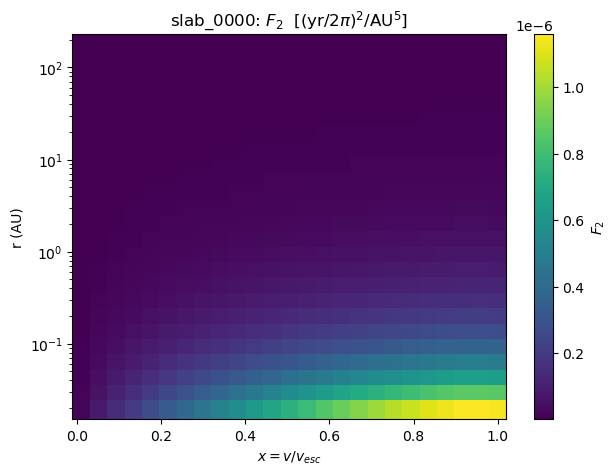

In [22]:
# ---- Read back and verify the HDF5 file ----
with h5py.File(out_path, "r") as h5:
    print("root attrs:")
    for k, v in h5.attrs.items():
        print(f"  {k} = {v}")
    print(f"\nslabs: {list(h5.keys())}\n")

    for name, g in h5.items():
        for ds in ("r", "v_norm", "F2", "F4", "E1"):
            assert ds in g, f"{name} missing dataset {ds}"
            assert np.all(np.isfinite(g[ds][...])), f"{name}/{ds} has non-finite values"
        nr, nv = g.attrs["n_r"], g.attrs["n_v"]
        assert g["r"].shape == (nr,)
        assert g["v_norm"].shape == (nv,)
        for ds in ("F2", "F4", "E1"):
            assert g[ds].shape == (nr, nv), f"{name}/{ds} shape {g[ds].shape} != {(nr, nv)}"
    print("shape / finiteness checks passed for all slabs.")

    # ---- spot-check one stored cell against a fresh F() call ----
    g = h5["slab_0000"]
    M = g.attrs["M_Msun"] * u.Msun
    m_star = g.attrs["m_star_Msun"] * u.Msun
    gamma = g.attrs["gamma"]
    r_inf = g.attrs["r_inf_pc"] * u.pc
    i, j = nr // 2, nv // 3
    r_chk = g["r"][i] * u.AU
    v_chk = g["v_norm"][j] * np.sqrt(2 * G * M / r_chk)   # v = x * v_esc
    F2_fresh = F(2, M, r_chk, v_chk, m_star, gamma, r_inf).to_value(F_nat)
    F2_stored = g["F2"][i, j]
    print(f"\nspot-check slab_0000 [{i},{j}]: stored={F2_stored:.6e}  fresh={F2_fresh:.6e}  "
          f"rel.diff={abs(F2_stored - F2_fresh) / abs(F2_fresh):.2e}")
    assert np.isclose(F2_stored, F2_fresh, rtol=1e-9)

    # ---- E1 -> 0 as x -> 1 (integration range v..v_esc collapses) ----
    print(f"E1[mid, last x] = {g['E1'][i, -1]:.3e}  (expected ~0 at x=1)")

    # ---- quick F2 heatmap for slab_0000 ----
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.pcolormesh(g["v_norm"][...], g["r"][...], g["F2"][...], shading="auto")
    ax.set_yscale("log")
    ax.set_xlabel(r"$x = v / v_{esc}$")
    ax.set_ylabel("r (AU)")
    ax.set_title(r"slab_0000: $F_2$  [(yr/2$\pi$)$^2$/AU$^5$]")
    fig.colorbar(im, ax=ax, label=r"$F_2$")
    plt.show()
